Initial book: LOB: best bid=99.5, best ask=100.5, spread=1.0
Depth (bid, ask): (200, 300)


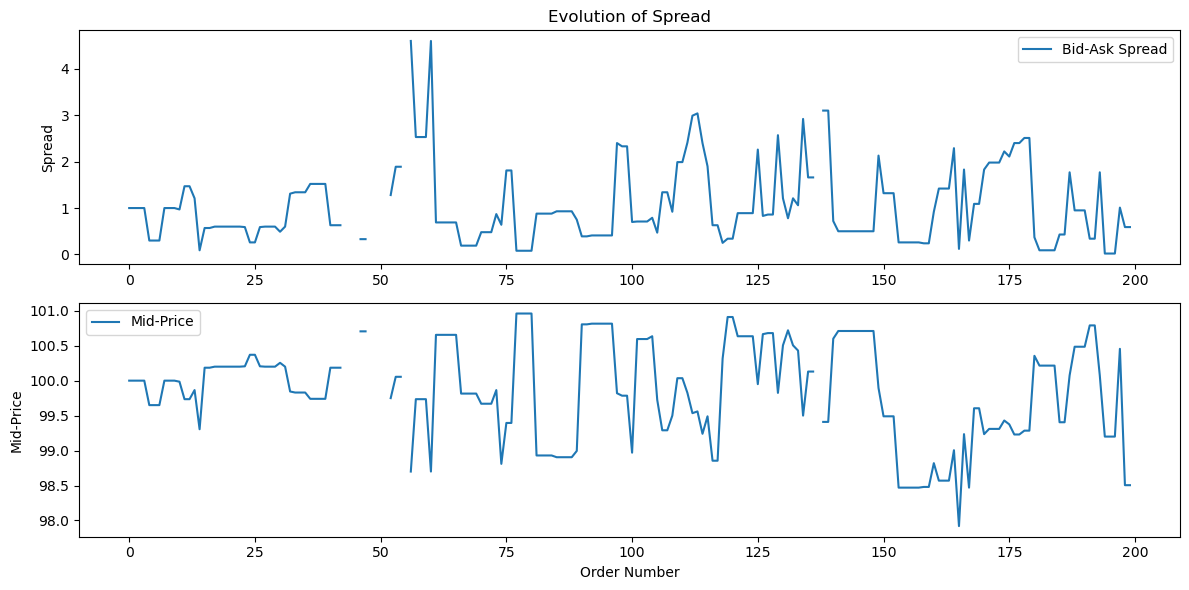


Final book state:
LOB: best bid=98.21, best ask=98.8, spread=0.5900000000000034
Total trades executed: 169
Average trade price: 99.73


In [3]:
# ============================================================
# PROJECT: LIMIT ORDER BOOK SIMULATION
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import heapq

# ------------------------------------------------------------
# 1. ORDER CLASS
# ------------------------------------------------------------
class Order:
    """Represents a single order."""
    def __init__(self, order_id, side, price, quantity, order_type='limit'):
        self.order_id = order_id
        self.side = side          # 'buy' or 'sell'
        self.price = price
        self.quantity = quantity
        self.order_type = order_type  # 'limit' or 'market'
        self.timestamp = None     # could be set later

    def __repr__(self):
        return f"Order({self.order_id}, {self.side}, {self.price}, {self.quantity}, {self.order_type})"


# ------------------------------------------------------------
# 2. LIMIT ORDER BOOK CLASS
# ------------------------------------------------------------
class LimitOrderBook:
    def __init__(self):
        # Bids: dictionary price -> total quantity (positive)
        self.bids = defaultdict(int)
        # Asks: dictionary price -> total quantity (positive)
        self.asks = defaultdict(int)
        # For efficient retrieval of best prices, we use heaps
        self.bid_heap = []   # max‑heap simulated by negative price
        self.ask_heap = []   # min‑heap (positive price)
        self.order_counter = 0
        self.trade_history = []   # list of (price, quantity, timestamp)

    def _update_heaps(self):
        """Rebuild heaps from current bids/asks (inefficient but simple)."""
        self.bid_heap = [(-p, q) for p, q in self.bids.items() if q > 0]
        self.ask_heap = [(p, q) for p, q in self.asks.items() if q > 0]
        heapq.heapify(self.bid_heap)
        heapq.heapify(self.ask_heap)

    def best_bid(self):
        """Return the highest bid price and its quantity."""
        if not self.bids:
            return None, 0
        # Since we use negative in heap, we need the max key
        best_price = max(self.bids.keys())
        return best_price, self.bids[best_price]

    def best_ask(self):
        """Return the lowest ask price and its quantity."""
        if not self.asks:
            return None, 0
        best_price = min(self.asks.keys())
        return best_price, self.asks[best_price]

    def spread(self):
        """Return bid‑ask spread (None if either side missing)."""
        best_bid, _ = self.best_bid()
        best_ask, _ = self.best_ask()
        if best_bid is None or best_ask is None:
            return None
        return best_ask - best_bid

    def mid_price(self):
        """Return mid‑price (average of best bid and ask)."""
        best_bid, _ = self.best_bid()
        best_ask, _ = self.best_ask()
        if best_bid is None or best_ask is None:
            return None
        return (best_bid + best_ask) / 2

    def depth(self):
        """Return total quantity at best bid and best ask."""
        _, best_bid_qty = self.best_bid()
        _, best_ask_qty = self.best_ask()
        return best_bid_qty, best_ask_qty

    def add_limit_order(self, side, price, quantity):
        """Add a limit order to the book."""
        self.order_counter += 1
        order = Order(self.order_counter, side, price, quantity, 'limit')
        # Check if it can be matched immediately
        if side == 'buy' and price >= self.best_ask()[0] if self.best_ask()[0] else False:
            # It's a marketable buy limit order → execute against asks
            self._execute_market_buy(quantity, price_limit=price)
        elif side == 'sell' and price <= self.best_bid()[0] if self.best_bid()[0] else False:
            # It's a marketable sell limit order → execute against bids
            self._execute_market_sell(quantity, price_limit=price)
        else:
            # Add to book
            if side == 'buy':
                self.bids[price] += quantity
                # Maintain heap: push negative price for max‑heap
                heapq.heappush(self.bid_heap, (-price, quantity))
            else:
                self.asks[price] += quantity
                heapq.heappush(self.ask_heap, (price, quantity))
        return order.order_id

    def add_market_order(self, side, quantity):
        """Add a market order (immediate execution)."""
        self.order_counter += 1
        order = Order(self.order_counter, side, None, quantity, 'market')
        if side == 'buy':
            self._execute_market_buy(quantity, price_limit=None)
        else:
            self._execute_market_sell(quantity, price_limit=None)
        return order.order_id

    def _execute_market_buy(self, quantity, price_limit=None):
        """Execute a market buy order (or marketable buy limit) against asks."""
        remaining = quantity
        total_cost = 0
        # Use a list to collect executed trades
        while remaining > 0 and self.asks:
            best_ask_price = min(self.asks.keys())
            # If price_limit is given (limit order), stop if price exceeds limit
            if price_limit is not None and best_ask_price > price_limit:
                # Order cannot cross this price; add remainder as limit order?
                # For simplicity, we assume market order is cancelled if not fully filled.
                # Here we'll leave the remaining quantity as a new limit order at the price limit.
                if remaining > 0:
                    self.bids[price_limit] += remaining
                    heapq.heappush(self.bid_heap, (-price_limit, remaining))
                break
            available = self.asks[best_ask_price]
            traded_qty = min(remaining, available)
            trade_price = best_ask_price
            # Record trade
            self.trade_history.append((trade_price, traded_qty))
            total_cost += trade_price * traded_qty
            remaining -= traded_qty
            # Update asks
            if available == traded_qty:
                del self.asks[best_ask_price]
            else:
                self.asks[best_ask_price] -= traded_qty
        # After execution, we could compute average price, but we'll just record.

    def _execute_market_sell(self, quantity, price_limit=None):
        """Execute a market sell order (or marketable sell limit) against bids."""
        remaining = quantity
        total_revenue = 0
        while remaining > 0 and self.bids:
            best_bid_price = max(self.bids.keys())
            if price_limit is not None and best_bid_price < price_limit:
                if remaining > 0:
                    self.asks[price_limit] += remaining
                    heapq.heappush(self.ask_heap, (price_limit, remaining))
                break
            available = self.bids[best_bid_price]
            traded_qty = min(remaining, available)
            trade_price = best_bid_price
            self.trade_history.append((trade_price, traded_qty))
            total_revenue += trade_price * traded_qty
            remaining -= traded_qty
            if available == traded_qty:
                del self.bids[best_bid_price]
            else:
                self.bids[best_bid_price] -= traded_qty

    def cancel_order(self, side, price, quantity=None):
        """Cancel a limit order (or part of it). If quantity is None, cancel all."""
        if side == 'buy':
            if price in self.bids:
                if quantity is None or quantity >= self.bids[price]:
                    del self.bids[price]
                else:
                    self.bids[price] -= quantity
            # Rebuild heaps after cancellation (inefficient but simple)
            self._update_heaps()
        elif side == 'sell':
            if price in self.asks:
                if quantity is None or quantity >= self.asks[price]:
                    del self.asks[price]
                else:
                    self.asks[price] -= quantity
            self._update_heaps()

    def __repr__(self):
        best_bid, _ = self.best_bid()
        best_ask, _ = self.best_ask()
        spread = self.spread()
        return f"LOB: best bid={best_bid}, best ask={best_ask}, spread={spread}"


# ------------------------------------------------------------
# 3. SIMULATION EXAMPLE
# ------------------------------------------------------------
def simulate_random_orders(lob, num_orders=100):
    """Generate random orders and feed them to the book."""
    import random
    random.seed(42)
    spread_history = []
    mid_history = []
    for i in range(num_orders):
        # Random order type: 70% limit, 30% market
        order_type = 'limit' if random.random() < 0.7 else 'market'
        side = 'buy' if random.random() < 0.5 else 'sell'
        quantity = random.randint(1, 100)

        if order_type == 'limit':
            # Price near current mid‑price if exists, else random around 100
            mid = lob.mid_price()
            if mid is not None:
                price = round(mid + random.uniform(-2, 2), 2)
            else:
                price = round(100 + random.uniform(-5, 5), 2)
            lob.add_limit_order(side, price, quantity)
        else:  # market
            lob.add_market_order(side, quantity)

        # Record metrics
        spread_history.append(lob.spread())
        mid_history.append(lob.mid_price())

    return spread_history, mid_history


# ------------------------------------------------------------
# 4. RUN SIMULATION AND PLOT
# ------------------------------------------------------------
if __name__ == "__main__":
    lob = LimitOrderBook()
    # Seed some initial liquidity (optional)
    lob.add_limit_order('buy', 99.50, 200)
    lob.add_limit_order('buy', 99.00, 150)
    lob.add_limit_order('sell', 100.50, 300)
    lob.add_limit_order('sell', 101.00, 250)

    print("Initial book:", lob)
    print("Depth (bid, ask):", lob.depth())

    # Simulate random orders
    spread_hist, mid_hist = simulate_random_orders(lob, num_orders=200)

    # Plot results
    plt.figure(figsize=(12, 6))
    plt.subplot(2,1,1)
    plt.plot(spread_hist, label='Bid‑Ask Spread')
    plt.ylabel('Spread')
    plt.title('Evolution of Spread')
    plt.legend()

    plt.subplot(2,1,2)
    plt.plot(mid_hist, label='Mid‑Price')
    plt.ylabel('Mid‑Price')
    plt.xlabel('Order Number')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print final statistics
    print("\nFinal book state:")
    print(lob)
    print(f"Total trades executed: {len(lob.trade_history)}")
    if lob.trade_history:
        avg_trade_price = sum(p*q for p,q in lob.trade_history) / sum(q for _,q in lob.trade_history)
        print(f"Average trade price: {avg_trade_price:.2f}")

In [4]:
# Additional analysis
import pandas as pd
trades_df = pd.DataFrame(lob.trade_history, columns=['price', 'quantity'])
print("Trade price statistics:")
print(trades_df['price'].describe())
print("\nVolume at price levels:")
# Group by price
volume_by_price = trades_df.groupby('price')['quantity'].sum()
print(volume_by_price)

Trade price statistics:
count    169.000000
mean      99.657751
std        0.978463
min       96.400000
25%       98.980000
50%       99.900000
75%      100.460000
max      101.110000
Name: price, dtype: float64

Volume at price levels:
price
96.40      58
96.90      53
97.86      55
97.98      81
98.03      37
         ... 
101.00    250
101.02     75
101.03     95
101.08     88
101.11     10
Name: quantity, Length: 79, dtype: int64
